In [1]:
import numpy as np
import scipy.io.wavfile as wav
import scipy.signal as sig
import scipy.linalg as lin
import matplotlib.pyplot as plt

In [2]:
# Constants
LP_ORDER = 10  # Linear Prediction Order
FRAME_LENGTH_MS = 25  # Frame length in milliseconds
FFT_SIZE = 1024  # FFT size in spectrum computation
DOWNSAMPLED_RATE = 8000  # Downsampled sampling rate
BIT_RESOLUTION = 16  # Bit resolution
BIT_RATE = 128000  # Bit rate of input

# Section 3
## Section 3.2

In [3]:
def lp_analysis(file_path):
    # Read the speech signal
    sample_rate, signal = wav.read(file_path)
    
    # Ensure signal is mono
    if signal.ndim > 1:
        signal = signal[:, 0]  # Take only one channel if stereo
    
    # Normalize signal
    signal = signal / np.max(np.abs(signal))
    
    # Define frame size in samples
    frame_size = int((FRAME_LENGTH_MS / 1000) * sample_rate)
    
    # Number of frames
    num_frames = int(len(signal) / frame_size)
    
    # Initialize the residual signal
    residual_signal = np.zeros_like(signal)
    
    # Initialize delay line
    delay_line = np.zeros(LP_ORDER)
    
    # Process each frame
    for i in range(num_frames):
        start = i * frame_size
        end = start + frame_size
        
        if end > len(signal):
            end = len(signal)
        
        frame = signal[start:end]
        
        # Apply Hamming window
        windowed_frame = frame * np.hamming(len(frame))
        
        # Compute autocorrelation
        r = np.correlate(windowed_frame, windowed_frame, mode='full')
        r = r[len(r)//2: len(r)//2 + LP_ORDER + 1]
        
        # Solve Yule-Walker equations for LP coefficients
        R = lin.toeplitz(r[:-1])
        rhs = -r[1:]
        a_coeffs = np.linalg.solve(R, rhs)
        a_coeffs = np.concatenate(([1], a_coeffs))
        
        # Compute residual by filtering the original (non-windowed) signal
        frame_residual = sig.lfilter(a_coeffs, [1], np.concatenate((delay_line, frame)))
        frame_residual = frame_residual[LP_ORDER:]
        
        # Store residual in the corresponding location
        residual_signal[start:end] = frame_residual[:len(frame)]
        
        # Update delay line for the next frame
        delay_line = frame[-LP_ORDER:]
    
    # Plot original and residual signals
    plt.figure(figsize=(12, 6))
    plt.plot(signal, label='Original Speech Signal', alpha=0.7)
    plt.plot(residual_signal, label='Residual Signal', alpha=0.7)
    plt.legend()
    plt.title('Original Speech vs. Residual Signal')
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.show()
    
    return residual_signal

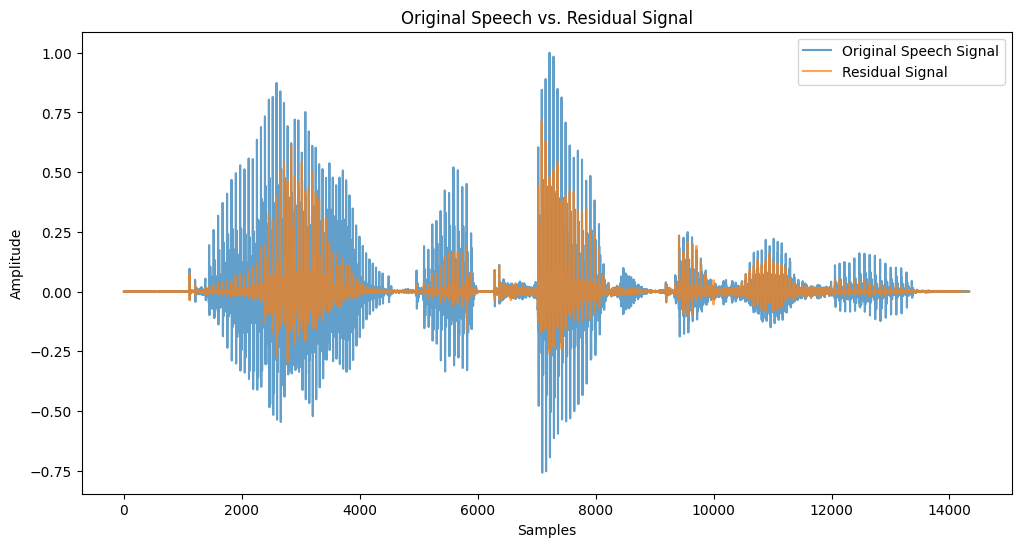

In [4]:
male_speech_residual = lp_analysis('Male_sentences_8kHz/si745_8kHz.wav')

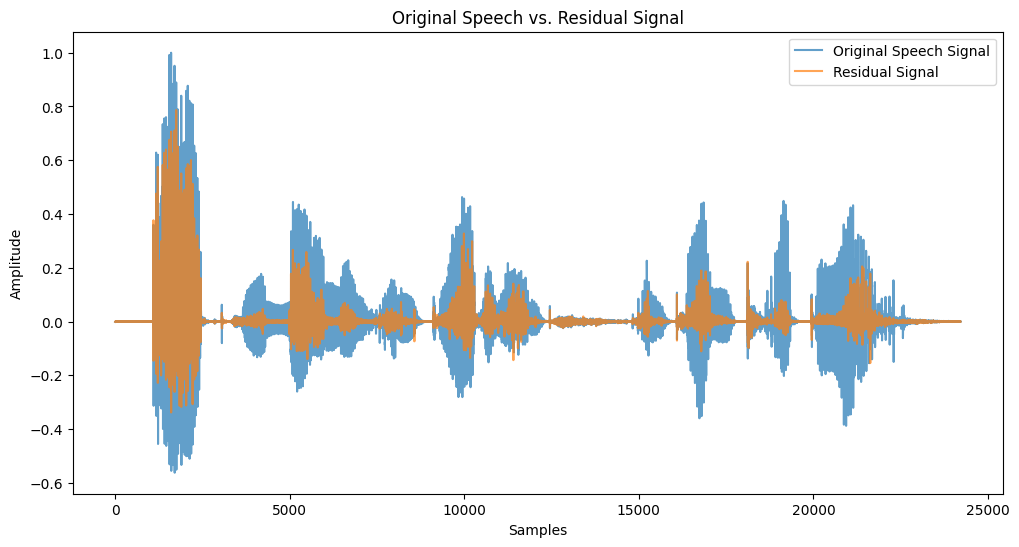

In [5]:
female_speech_residual = lp_analysis('Female_sentences_8kHz/si747_8kHz.wav')

In [6]:
def lp_synthesis(residual_signal, file_path):
    # Read the speech signal
    sample_rate, original_signal = wav.read(file_path)
    
    # Ensure signal is mono
    if original_signal.ndim > 1:
        original_signal = original_signal[:, 0]
    
    # Normalize original signal
    original_signal = original_signal / np.max(np.abs(original_signal))
    
    # Define frame size in samples
    frame_size = int((FRAME_LENGTH_MS / 1000) * sample_rate)
    
    # Number of frames
    num_frames = int(len(residual_signal) / frame_size)
    
    # Initialize the reconstructed signal
    reconstructed_signal = np.zeros_like(residual_signal)
    
    # Initialize delay line
    delay_line = np.zeros(LP_ORDER)
    
    # Process each frame
    for i in range(num_frames):
        start = i * frame_size
        end = start + frame_size
        
        if end > len(residual_signal):
            end = len(residual_signal)
        
        frame_residual = residual_signal[start:end]
        
        # Compute autocorrelation
        r = np.correlate(original_signal[start:end] * np.hamming(len(frame_residual)),
                         original_signal[start:end] * np.hamming(len(frame_residual)), mode='full')
        r = r[len(r)//2: len(r)//2 + LP_ORDER + 1]
        
        # Solve Yule-Walker equations for LP coefficients
        R = lin.toeplitz(r[:-1])
        rhs = -r[1:]
        a_coeffs = np.linalg.solve(R, rhs)
        a_coeffs = np.concatenate(([1], a_coeffs))
        
        # Compute synthesized signal by filtering the residual through 1/A(z)
        frame_synthesized = sig.lfilter([1], a_coeffs, np.concatenate((delay_line, frame_residual)))
        frame_synthesized = frame_synthesized[LP_ORDER:]
        
        # Store synthesized frame
        reconstructed_signal[start:end] = frame_synthesized[:len(frame_residual)]
        
        # Update delay line for next frame
        delay_line = reconstructed_signal[start:end][-LP_ORDER:]
    
    # Plot original and synthesized signals
    plt.figure(figsize=(12, 6))
    plt.plot(original_signal, label='Original Speech Signal', alpha=0.7)
    plt.plot(reconstructed_signal, label='Synthesized Signal', alpha=0.7)
    plt.legend()
    plt.title('Original Speech vs. Synthesized Signal')
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.show()

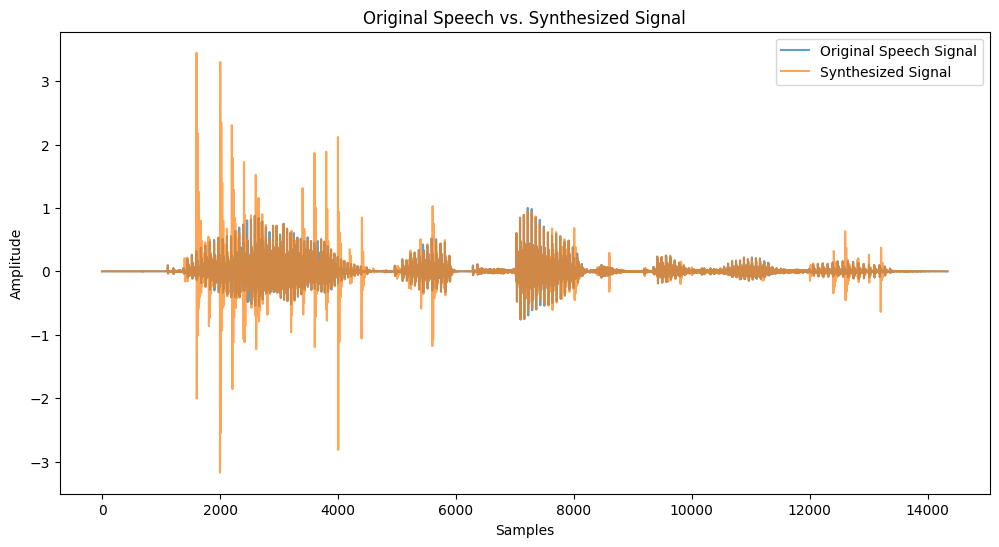

In [7]:
lp_synthesis(male_speech_residual, 'Male_sentences_8kHz/si745_8kHz.wav')

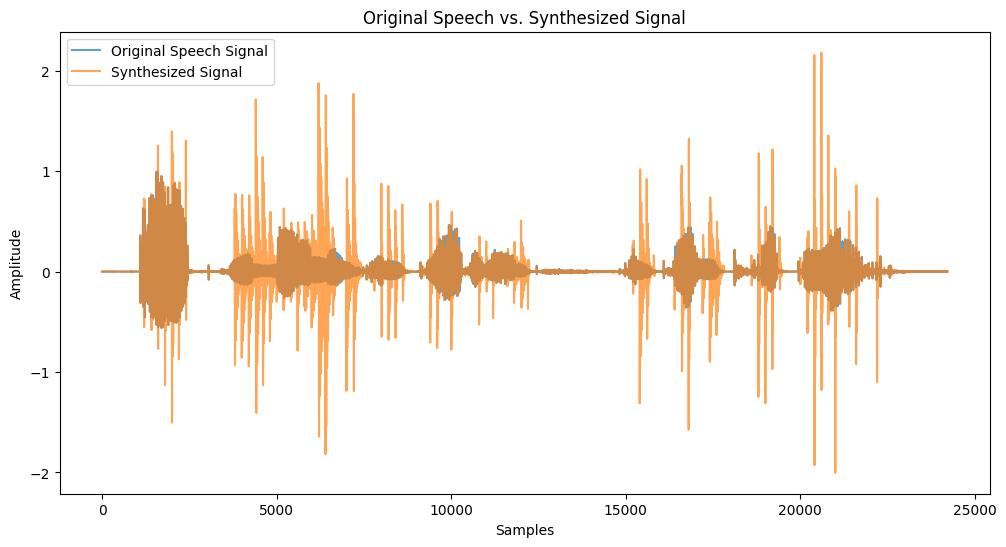

In [8]:
lp_synthesis(female_speech_residual, 'Female_sentences_8kHz/si747_8kHz.wav')

## Section 3.3

In [9]:
def compute_spectral_distortion(original_spectrum, quantized_spectrum):
    """Computes spectral distortion (SD) in dB."""
    sd = np.mean((10 * np.log10(original_spectrum) - 10 * np.log10(quantized_spectrum))**2)
    return sd

In [10]:
def lpc_to_lattice(lpc_coeffs):
    """Convert LPC coefficients to lattice (reflection) coefficients."""
    order = len(lpc_coeffs) - 1
    lattice_coeffs = np.zeros(order)
    
    for i in range(order, 0, -1):
        lattice_coeffs[i - 1] = -lpc_coeffs[i]
        for j in range(1, i):
            lpc_coeffs[j] = (lpc_coeffs[j] + lattice_coeffs[i - 1] * lpc_coeffs[i - j]) / (1 - lattice_coeffs[i - 1] ** 2)
    
    return lattice_coeffs

In [11]:
def quantize_lattice(lattice_coeffs, num_bits):
    """Quantize lattice coefficients using uniform scalar quantization."""
    step_size = 2 / (2**num_bits)  # Define step size for uniform quantization
    quantized_lattice = np.round(lattice_coeffs / step_size) * step_size
    return quantized_lattice

In [12]:
def lattice_to_lpc(lattice_coeffs):
    """Convert quantized lattice coefficients back to LPC form."""
    order = len(lattice_coeffs)
    lpc_coeffs = np.zeros(order + 1)
    lpc_coeffs[0] = 1.0
    
    for i in range(order):
        k = lattice_coeffs[i]
        for j in range(1, i + 1):
            lpc_coeffs[j] -= k * lpc_coeffs[i - j + 1]
    
    return lpc_coeffs

In [13]:
def compute_avg_spectral_distortion(file_path):
    """Quantize LP synthesis filters and compute spectral distortion for different bit levels."""
    num_bits_list = [5, 4, 3]
    spectral_distortions = {bits: [] for bits in num_bits_list}
    
    sample_rate, signal = wav.read(file_path)
    if signal.ndim > 1:
        signal = signal[:, 0]  # Convert to mono if stereo
    signal = signal / np.max(np.abs(signal))
    frame_size = int((FRAME_LENGTH_MS / 1000) * sample_rate)
    num_frames = int(len(signal) / frame_size)
    
    for i in range(num_frames):
        start = i * frame_size
        end = start + frame_size
        if end > len(signal):
            end = len(signal)
        frame = signal[start:end]
        
        # Compute LPC coefficients
        windowed_frame = frame * np.hamming(len(frame))
        r = np.correlate(windowed_frame, windowed_frame, mode='full')
        r = r[len(r)//2: len(r)//2 + LP_ORDER + 1]
        R = lin.toeplitz(r[:-1])
        rhs = -r[1:]
        lpc_coeffs = np.linalg.solve(R, rhs)
        lpc_coeffs = np.concatenate(([1], lpc_coeffs))
        
        # Convert LPC to lattice form
        lattice_coeffs = lpc_to_lattice(lpc_coeffs)
        
        for num_bits in num_bits_list:
            # Quantize lattice coefficients
            quantized_lattice = quantize_lattice(lattice_coeffs, num_bits)
            
            # Convert back to LPC
            quantized_lpc = lattice_to_lpc(quantized_lattice)
            
            # Compute power spectra
            original_spectrum = np.abs(np.fft.fft(lpc_coeffs, n=FFT_SIZE))**2
            quantized_spectrum = np.abs(np.fft.fft(quantized_lpc, n=FFT_SIZE))**2
            
            # Compute spectral distortion
            sd = compute_spectral_distortion(original_spectrum, quantized_spectrum)
            spectral_distortions[num_bits].append(sd)
    
    avg_sd = {bits: np.mean(spectral_distortions[bits]) for bits in num_bits_list}
    print("Average Spectral Distortion for", file_path, avg_sd)

In [14]:
compute_avg_spectral_distortion('Male_sentences_8kHz/si745_8kHz.wav')

Average Spectral Distortion for Male_sentences_8kHz/si745_8kHz.wav {5: np.float64(641.1719310501442), 4: np.float64(641.1719310501442), 3: np.float64(641.1719310501442)}


In [15]:
compute_avg_spectral_distortion('Female_sentences_8kHz/si747_8kHz.wav')

Average Spectral Distortion for Female_sentences_8kHz/si747_8kHz.wav {5: np.float64(378.3200773125902), 4: np.float64(378.3200773125902), 3: np.float64(378.3200773125902)}


In [16]:
def select_high_amplitude_frame(file_path):
    """Select the frame with the highest amplitude from the speech signal."""
    sample_rate, signal = wav.read(file_path)
    if signal.ndim > 1:
        signal = signal[:, 0]  # Convert to mono if stereo
    signal = signal / np.max(np.abs(signal))
    frame_size = int((FRAME_LENGTH_MS / 1000) * sample_rate)
    num_frames = int(len(signal) / frame_size)
    
    max_energy = 0
    best_frame = None
    
    for i in range(num_frames):
        start = i * frame_size
        end = start + frame_size
        if end > len(signal):
            end = len(signal)
        frame = signal[start:end]
        
        # Compute energy of the frame
        energy = np.sum(frame ** 2)
        if energy > max_energy:
            max_energy = energy
            best_frame = frame
    
    return best_frame

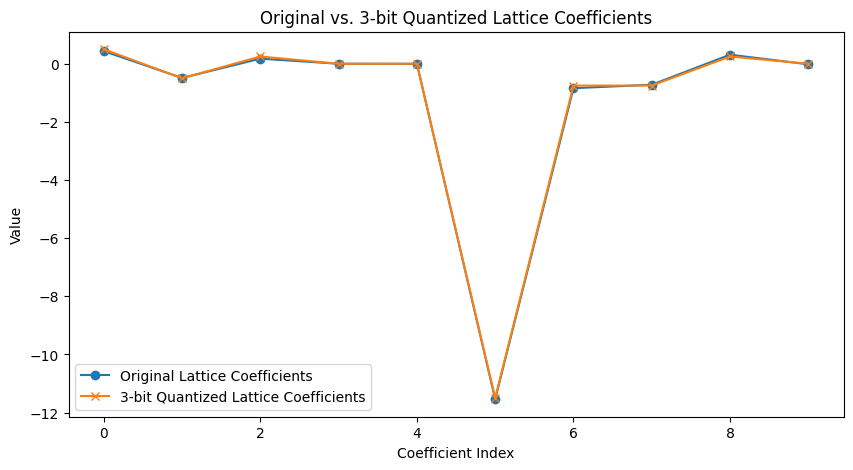

In [17]:
best_frame = select_high_amplitude_frame('Male_sentences_8kHz/si745_8kHz.wav')

# Compute LPC and lattice coefficients
windowed_frame = best_frame * np.hamming(len(best_frame))
r = np.correlate(windowed_frame, windowed_frame, mode='full')
r = r[len(r)//2: len(r)//2 + LP_ORDER + 1]
R = lin.toeplitz(r[:-1])
rhs = -r[1:]
lpc_coeffs = np.linalg.solve(R, rhs)
lpc_coeffs = np.concatenate(([1], lpc_coeffs))
lattice_coeffs = lpc_to_lattice(lpc_coeffs)
quantized_lattice_bit_3 = quantize_lattice(lattice_coeffs, 3)

# Plot original vs. 3-bit quantized lattice coefficients
plt.figure(figsize=(10, 5))
plt.plot(lattice_coeffs, label='Original Lattice Coefficients', marker='o')
plt.plot(quantized_lattice_bit_3, label='3-bit Quantized Lattice Coefficients', marker='x')
plt.legend()
plt.title('Original vs. 3-bit Quantized Lattice Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Value')
plt.show()

In [18]:
def lp_analysis_quantized(file_path, quantized_lattice_coef=quantized_lattice_bit_3):
    """Perform LP analysis using quantized lattice coefficients."""
    sample_rate, signal = wav.read(file_path)
    if signal.ndim > 1:
        signal = signal[:, 0]  # Convert to mono if stereo
    signal = signal / np.max(np.abs(signal))
    frame_size = int((FRAME_LENGTH_MS / 1000) * sample_rate)
    num_frames = int(len(signal) / frame_size)
    residual_signal = np.zeros_like(signal)
    delay_line = np.zeros(LP_ORDER)
    
    a_coeffs = lattice_to_lpc(quantized_lattice_coef)
    
    for i in range(num_frames):
        start = i * frame_size
        end = start + frame_size
        if end > len(signal):
            end = len(signal)
        frame = signal[start:end]
        
        frame_residual = sig.lfilter(a_coeffs, [1], np.concatenate((delay_line, frame)))
        frame_residual = frame_residual[LP_ORDER:]
        residual_signal[start:end] = frame_residual[:len(frame)]
        delay_line = frame[-LP_ORDER:]
    
    plt.figure(figsize=(12, 6))
    plt.plot(signal, label='Original Speech Signal', alpha=0.7)
    plt.plot(residual_signal, label='Residual Signal', alpha=0.7)
    plt.legend()
    plt.title('Original Speech vs. Residual Signal (Quantized LP)')
    plt.xlabel('Samples')
    plt.ylabel('Amplitude')
    plt.show()
    
    return residual_signal

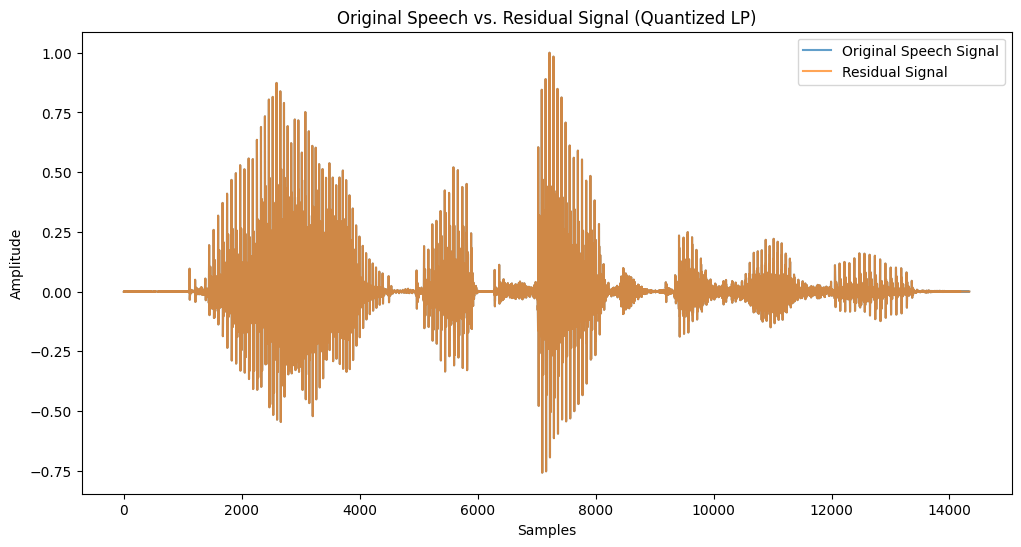

In [19]:
male_speech_residual_quantized = lp_analysis_quantized('Male_sentences_8kHz/si745_8kHz.wav')

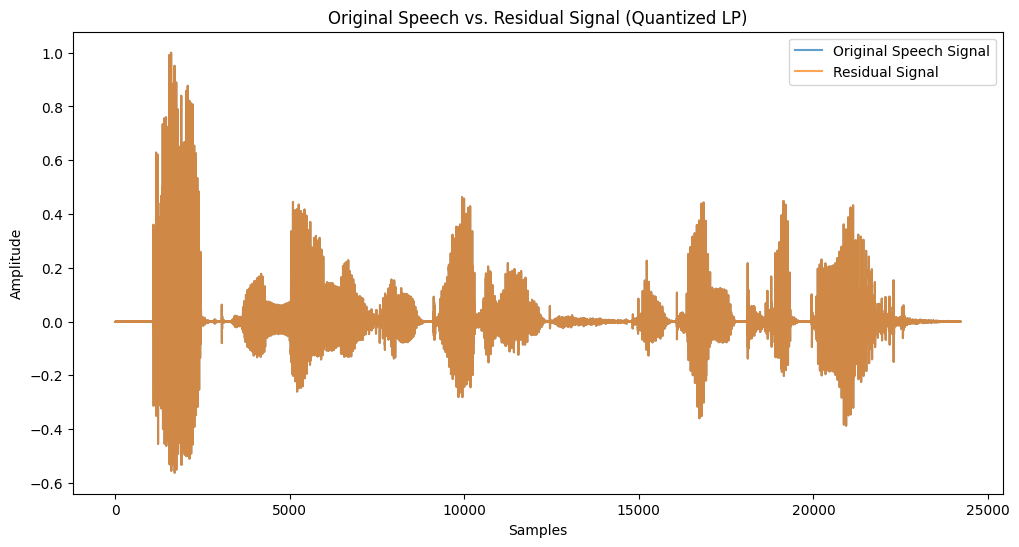

In [20]:
female_speech_residual_quantized = lp_analysis_quantized('Female_sentences_8kHz/si747_8kHz.wav')

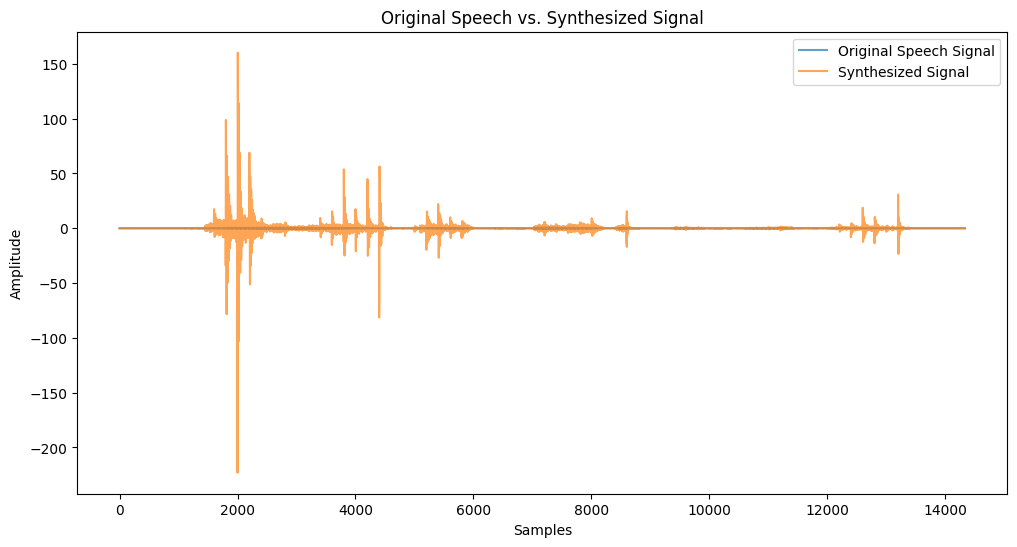

In [21]:
lp_synthesis(male_speech_residual_quantized, 'Male_sentences_8kHz/si745_8kHz.wav')

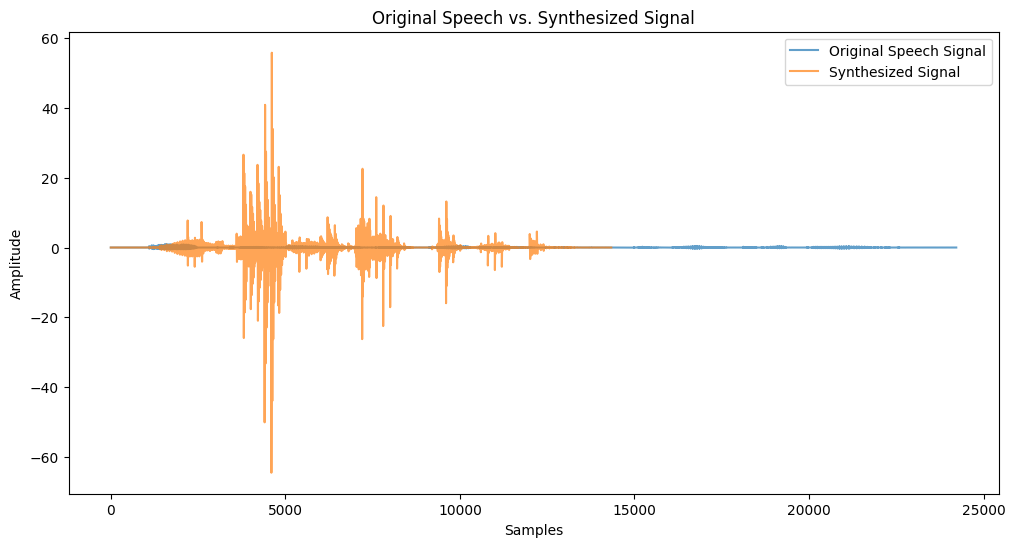

In [22]:
lp_synthesis(male_speech_residual_quantized, 'Female_sentences_8kHz/si747_8kHz.wav')